In [ ]:
library(Seurat)
library(SeuratData)
library(patchwork)
library(ggplot2)
library(purrr)
library(dplyr)
library(stringr)

In [30]:
library( RColorBrewer)

In [17]:
GCA_obj_subset <- readRDS(file = "GCA_obj_subset.Rdata")

In [18]:
GCA_obj_subset@meta.data[,c(1:7,14)] -> GCA_obj_subset@meta.data

In [1]:
sce.pub.Rds <- readRDS("sce.pub.Rds")

In [3]:
sce.pub.Rds@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,sample,patient,timepoint,tissue,tissue2,preparation,percent.mt,⋯,rRNA1,rRNA2,rRNA3,stress1,SCT_snn_res.1.2,seurat_clusters,cellsubtype,celltype,subcompartment,compartment
,<fct>,<dbl>,<int>,<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<chr>,<chr>,<chr>,<chr>
AAACCTGAGACATAAC-ESCC-FLJG_ICI-4W_Tumor_frozen,SeuratProject,749,359,ESCC-FLJG_ICI-4W_Tumor_frozen,ESCC-FLJG,ICI-4W,ESCC,ESCC,frozen,21.361816,⋯,0.000000000,4.020901,0.000000000,0.06291710,0,0,Tcell_CD4_GenNonCirc1,Tcell_CD4_GenNonCirc,Tcell,Immune-Lymphocyte
AAACCTGGTCGATTGT-ESCC-FLJG_ICI-4W_Tumor_frozen,SeuratProject,755,454,ESCC-FLJG_ICI-4W_Tumor_frozen,ESCC-FLJG,ICI-4W,ESCC,ESCC,frozen,8.874172,⋯,0.000000000,3.188773,0.000000000,-0.16007674,4,4,Tcell_CD4_Treg,Tcell_CD4_Treg,Tcell,Immune-Lymphocyte
AAAGATGGTTGTGGCC-ESCC-FLJG_ICI-4W_Tumor_frozen,SeuratProject,917,531,ESCC-FLJG_ICI-4W_Tumor_frozen,ESCC-FLJG,ICI-4W,ESCC,ESCC,frozen,15.485278,⋯,0.000000000,3.939584,0.000000000,0.09439695,20,20,VascEndo_TAEC3_APLNRhi,VascEndo_TAEC,Vascular_Endothelium,Stroma
AAAGTAGAGTAGATGT-ESCC-FLJG_ICI-4W_Tumor_frozen,SeuratProject,1813,923,ESCC-FLJG_ICI-4W_Tumor_frozen,ESCC-FLJG,ICI-4W,ESCC,ESCC,frozen,8.990623,⋯,0.000000000,3.595488,0.000000000,0.17428589,48,48,ESCC-FLJG_2,ESCC,Squamous_Epithelium,Epithelium
AACTCCCAGCTACCGC-ESCC-FLJG_ICI-4W_Tumor_frozen,SeuratProject,1442,760,ESCC-FLJG_ICI-4W_Tumor_frozen,ESCC-FLJG,ICI-4W,ESCC,ESCC,frozen,7.350902,⋯,0.000000000,3.471586,0.000000000,0.16436520,48,48,ESCC-FLJG_2,ESCC,Squamous_Epithelium,Epithelium
ACACCCTTCTGCAAGT-ESCC-FLJG_ICI-4W_Tumor_frozen,SeuratProject,9220,2655,ESCC-FLJG_ICI-4W_Tumor_frozen,ESCC-FLJG,ICI-4W,ESCC,ESCC,frozen,5.759219,⋯,0.000000000,3.268413,0.000000000,-0.15753341,48,48,ESCC-FLJG_1,ESCC,Squamous_Epithelium,Epithelium
ACACCGGAGAGTTGGC-ESCC-FLJG_ICI-4W_Tumor_frozen,SeuratProject,2251,1107,ESCC-FLJG_ICI-4W_Tumor_frozen,ESCC-FLJG,ICI-4W,ESCC,ESCC,frozen,9.817859,⋯,0.000000000,3.866749,0.000000000,-0.01328120,48,48,ESCC-FLJG_2,ESCC,Squamous_Epithelium,Epithelium
ACACTGAGTGCTCTTC-ESCC-FLJG_ICI-4W_Tumor_frozen,SeuratProject,658,425,ESCC-FLJG_ICI-4W_Tumor_frozen,ESCC-FLJG,ICI-4W,ESCC,ESCC,frozen,16.869301,⋯,0.000000000,3.981187,0.000000000,-0.02712354,1,1,Pericyte_CD36hi,Pericyte,Fibroblast_Mural,Stroma
ACAGCCGTCCAGATCA-ESCC-FLJG_ICI-4W_Tumor_frozen,SeuratProject,9364,2722,ESCC-FLJG_ICI-4W_Tumor_frozen,ESCC-FLJG,ICI-4W,ESCC,ESCC,frozen,7.710380,⋯,0.000000000,3.502568,0.000000000,0.10546962,48,48,ESCC-FLJG_1,ESCC,Squamous_Epithelium,Epithelium


In [20]:
map <- function(ref,query){
    gca.anchors <- FindTransferAnchors(reference = ref, query = query, dims = 1:30,
                                       normalization.method = 'SCT',reference.reduction = "pca")
    predictions <- TransferData(anchorset = gca.anchors, refdata = ref$celltype2, dims = 1:30)
    query <- AddMetaData(query, metadata = predictions)
    return(query)
}

### for lymphocytes

In [21]:
GCA_obj_subset_lymphocyte <- subset(x = GCA_obj_subset, Maincelltype == "Lymphocyte")

In [22]:
sce.pub_lymphcytes  <- subset(x = sce.pub.Rds,compartment == "Immune-Lymphocyte")

In [23]:
sce.pub_lymphcytes@meta.data$celltype %>% unique()

[1] "Tcell_CD4_GenNonCirc" "Tcell_CD4_Treg"       "Plasma_cell_IgG"     
 [4] "NKcell"               "Tcell_CD4_GenCirc"    "Tcell_CD8_TRM"       
 [7] "Tcell_CD4_TH17"       "Plasma_cell_IgA"      "Bcell_Mature"        
[10] "Tcell_CD8_NonTRM"     "Tcell_CD4_TFHX13"     "Plasma_cell_IgM"     
[13] "Bcell_Naive"          "Tcell_Prolif"         "Plasma_cell_Prolif"  
[16] "Bcell_GC"

In [24]:
sce.pub_lymphcytes@meta.data %>% mutate(celltype2 = case_when(str_detect(celltype,'Tcell_CD4') ~ "CD4_Tcell",
                                                             str_detect(celltype,'Tcell_CD8') ~ "CD8_Tcell",
                                                             str_detect(celltype,'NKcell') ~ "NKcell",
                                                             str_detect(celltype,'Bcell') ~ "Bcell",
                                                             str_detect(celltype,'Treg') ~ "Treg",
                                                             str_detect(celltype,'Plasma') ~ "Plasma",
                                                             str_detect(celltype,'Tcell_Prolif') ~ "Tcell_Prolif"
                                                             )) -> sce.pub_lymphcytes@meta.data 

In [ ]:
GCA_obj_subset_lymphocyte <- map(sce.pub_lymphcytes,GCA_obj_subset_lymphocyte)

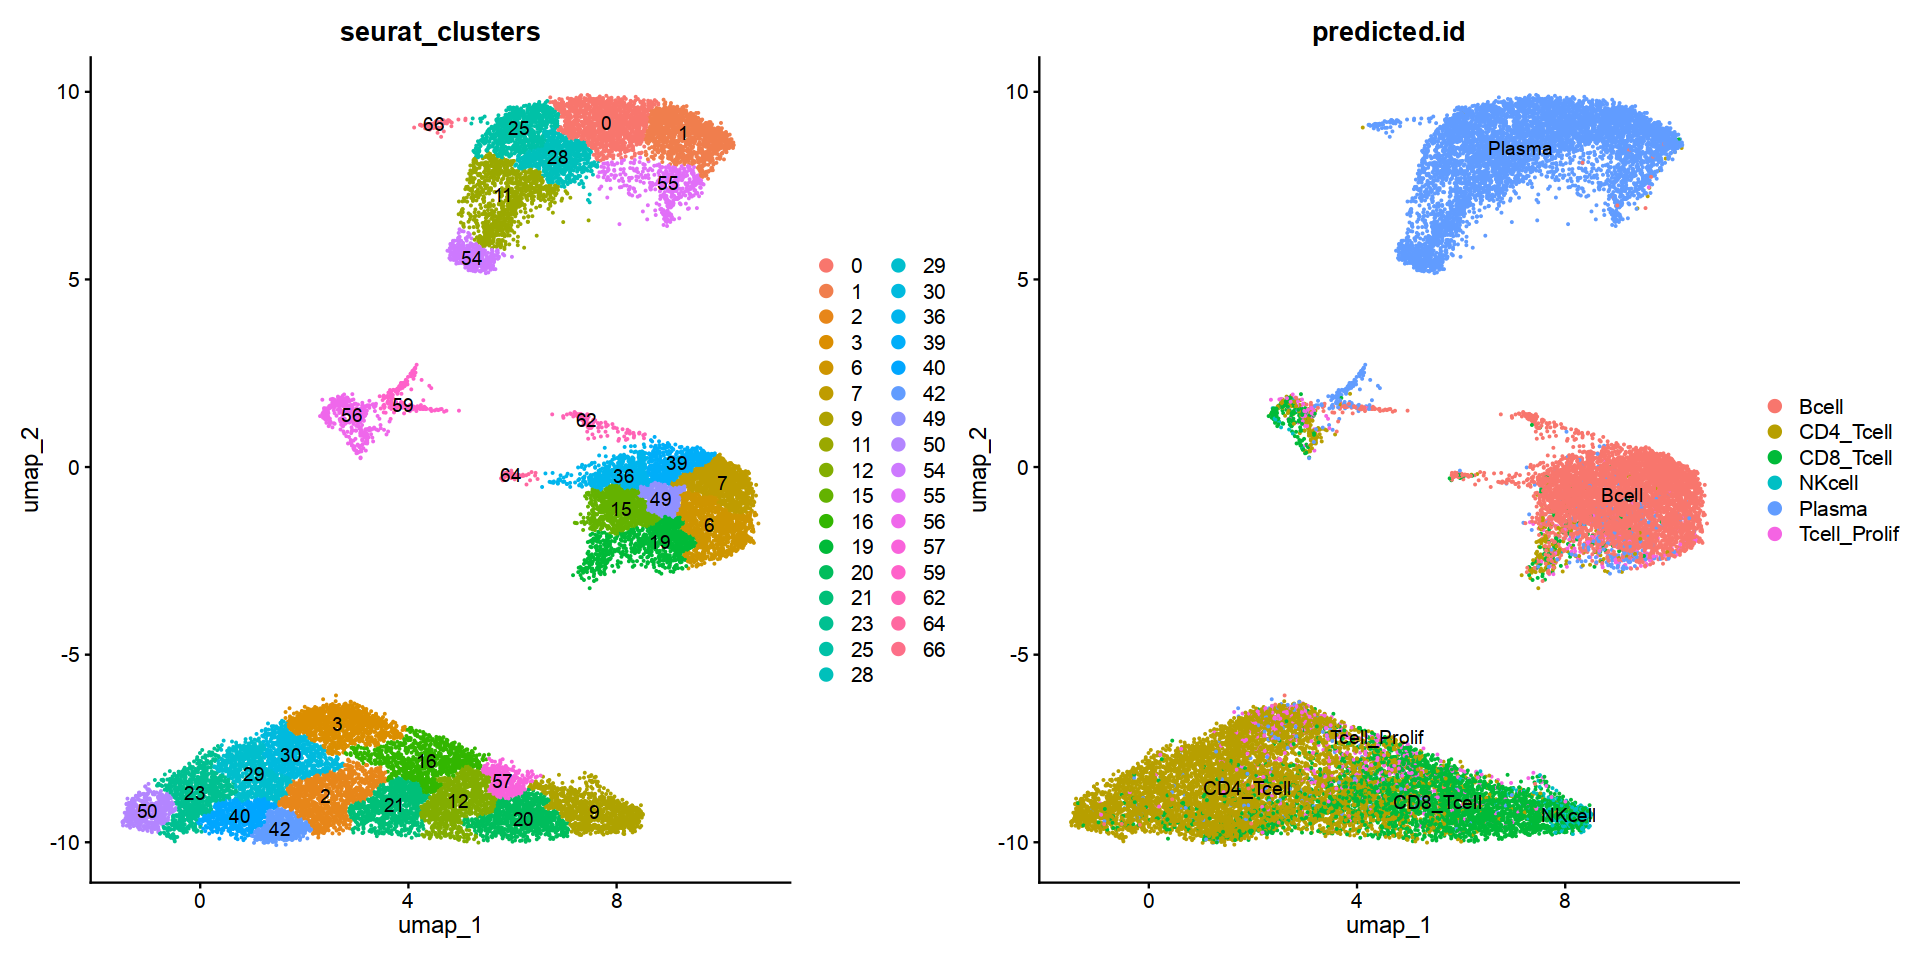

In [26]:
# Visualization
options(repr.plot.height=8,repr.plot.width=16)
DimPlot(GCA_obj_subset_lymphocyte, reduction = "umap",group.by = c("predicted.id"),label = TRUE,ncol=2)

### for Phogacytes

In [27]:
GCA_obj_subset_Phagocyte <- subset(x = GCA_obj_subset, Maincelltype == "Phagocyte")

sce.pub_Phagocyte  <- subset(x = sce.pub.Rds,compartment == "Immune-Phagocyte")

sce.pub_Phagocyte@meta.data$celltype %>% unique()

[1] "DC_Mature_LAMP3hi"      "DC_cDC2"                "Macrophage_TAM"        
 [4] "Monocyte"               "Mast_cell"              "DC_Plasmacytoid"       
 [7] "Macrophage_DiffM1-like" "Macrophage_M2-like"     "DC_cDC1"               
[10] "Neutrophil"

In [28]:
sce.pub_Phagocyte@meta.data %>% mutate(celltype2 = case_when(str_detect(celltype,'DC') ~ "DC",
                                                              str_detect(celltype,'Tcell_CD8') ~ "CD8_Tcell",
                                                             str_detect(celltype,'Macrophage_DiffM1') ~ "Macrophage_M1",
                                                             str_detect(celltype,'Macrophage_TAM') ~ "Macrophage_TAM",
                                                             str_detect(celltype,'Macrophage_M2-like') ~ "Macrophage_M2",
                                                             str_detect(celltype,'Neutrophil') ~ "Neutrophil",
                                                             str_detect(celltype,'Mast_cell') ~ "Mast_cell",
                                                              str_detect(celltype,'Monocyte') ~ "Monocyte"
                                                             )) -> sce.pub_Phagocyte@meta.data 

In [ ]:
GCA_obj_subset_Phagocyte <- map(sce.pub_Phagocyte,GCA_obj_subset_Phagocyte)

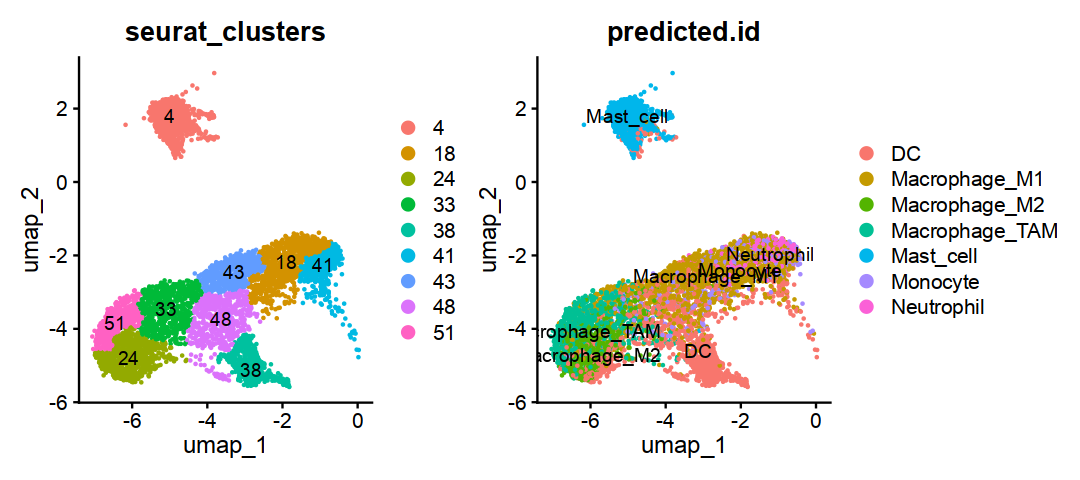

In [85]:
# Visualization
options(repr.plot.height=4,repr.plot.width=9)
DimPlot(GCA_obj_subset_Phagocyte, reduction = "umap",group.by = c("seurat_clusters","predicted.id"),label = TRUE,ncol=2)

### for epith

In [ ]:
GCA_obj_subset_epi <- subset(x = GCA_obj_subset, Maincelltype == "Epithelium")

In [90]:
GCA_obj_subset_epi@meta.data %>% head()

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,RNA_snn_res.1.2,seurat_clusters,Maincelltype,subcelltype
,<fct>,<dbl>,<dbl>,<chr>,<dbl>,<fct>,<fct>,<chr>,<chr>
AAACGAAGTTACTCAG-1-SC005,SeuratProject,6821,2750,SC005,7.257000,10,10,Epithelium,Epithelium
AAAGAACGTAAGGAGA-1-SC005,SeuratProject,3441,1066,SC005,2.906132,14,14,Epithelium,Epithelium
AAAGAACGTGGCGCTT-1-SC005,SeuratProject,1888,972,SC005,12.235169,10,10,Epithelium,Epithelium
AAAGGGCAGTAGTCTC-1-SC005,SeuratProject,2239,1278,SC005,6.252791,14,14,Epithelium,Epithelium
AAAGGTAGTCTTCAAG-1-SC005,SeuratProject,996,732,SC005,11.044177,5,5,Epithelium,Epithelium
AAAGGTAGTTGCTGAT-1-SC005,SeuratProject,2145,1043,SC005,5.034965,14,14,Epithelium,Epithelium


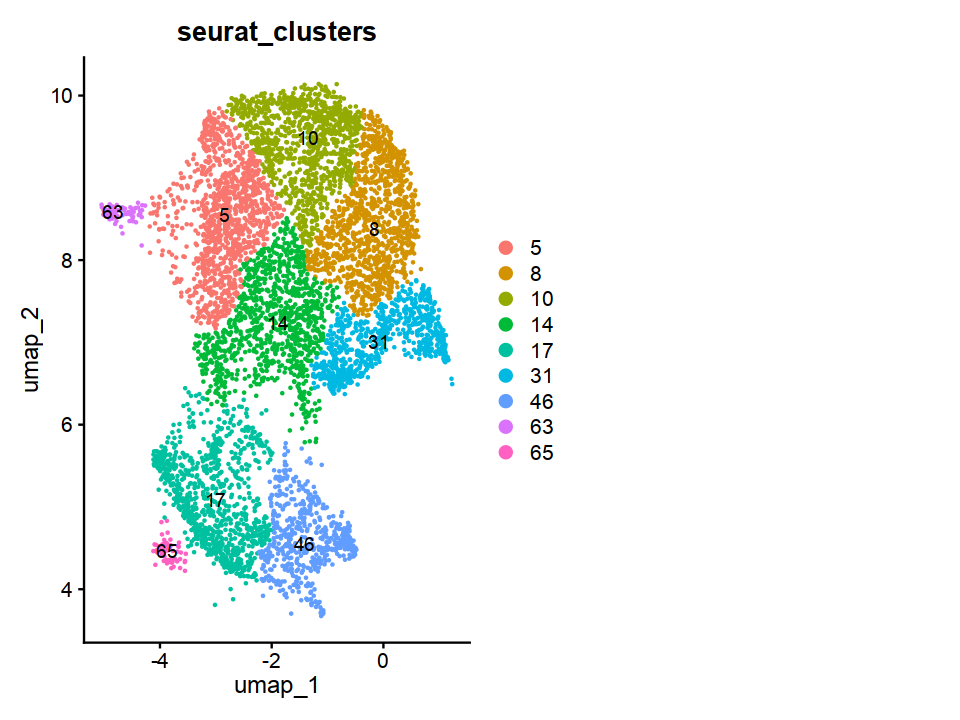

In [93]:
options(repr.plot.height=6,repr.plot.width=8)
DimPlot(GCA_obj_subset_epi, reduction = "umap",group.by = c("seurat_clusters"),
        label = TRUE,ncol=2)

### for stromal

In [31]:
GCA_obj_subset_strom <- subset(x = GCA_obj_subset, Maincelltype == "Stroma")
sce.pub_strom  <- subset(x = sce.pub.Rds,compartment == "Stroma")
sce.pub_strom@meta.data$celltype %>% unique()

[1] "VascEndo_TAEC"          "Pericyte"               "SMC_Vascular"          
 [4] "VascEndo_PCV_NonInflam" "VascEndo_Capillary"     "VascEndo_Arterial"     
 [7] "Fibroblast_TAF"         "Fibroblast_Papillary"   "Fibroblast_Reticular"  
[10] "Schwann_cell"           "Fibroblast_POSTNhi"     "SMC_NonVascular"       
[13] "LymphEndo"              "VascEndo_PCV_Inflam"

In [32]:
sce.pub_strom@meta.data %>% mutate(celltype2 = case_when(str_detect(celltype,'Endo') ~ "Endothelial",
                                                              str_detect(celltype,'Fibroblast') ~ "Fibroblast",
                                                             str_detect(celltype,'Pericyte') ~ "Pericyte",
                                                             str_detect(celltype,'SMC') ~ "SMC",
                                                             str_detect(celltype,'LymphEndo') ~ "LymphEndo",
                                                         str_detect(celltype,'Schwann_cell') ~ "Schwann_cell"
                                                             )) -> sce.pub_strom@meta.data 

In [ ]:
GCA_obj_subset_strom <- map(sce.pub_strom,GCA_obj_subset_strom)

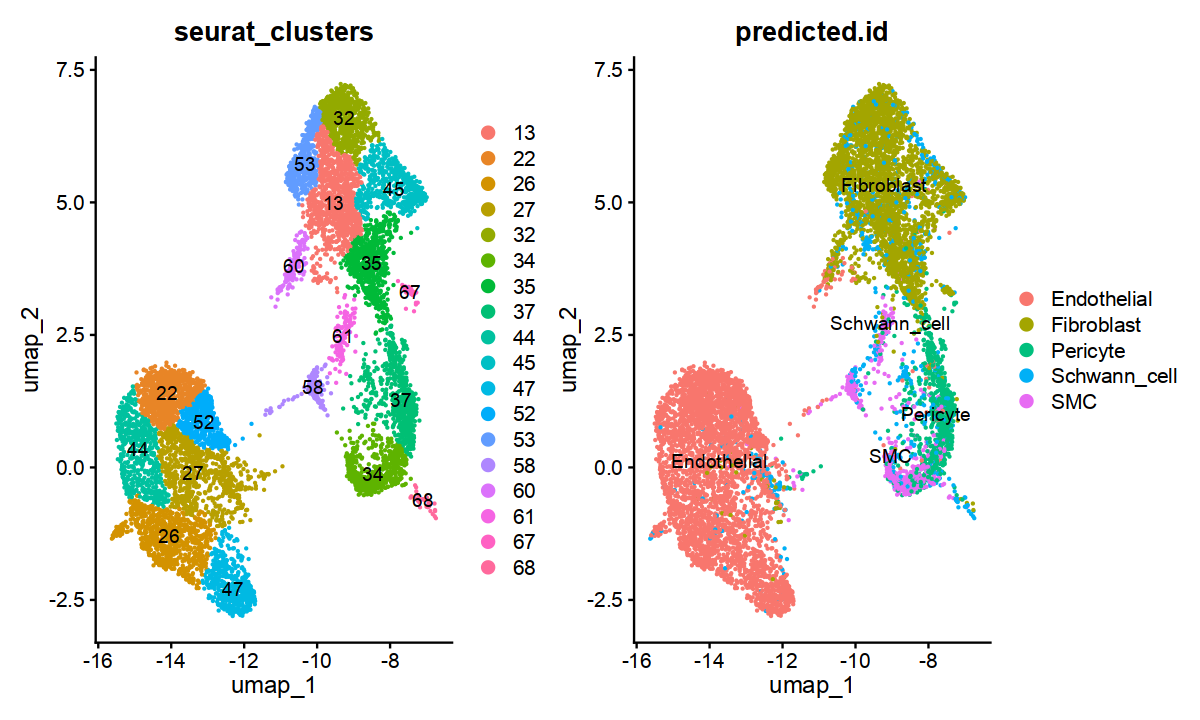

In [34]:
# Visualization
options(repr.plot.height=6,repr.plot.width=10)
DimPlot(GCA_obj_subset_strom, reduction = "umap",group.by = c("seurat_clusters","predicted.id"),label = TRUE,ncol=2)

### full annotation

In [94]:
GCA_obj_subset@meta.data %>% mutate(subcelltype = case_when(
                          seurat_clusters %in% c(10,5,8,63,14,31) ~ "Epi_tumor",
                            seurat_clusters %in% c(17,46,65) ~ "Epi_normal",
                          seurat_clusters %in% c(12,57,20,9,56) ~ "Tcell_CD8",
                          seurat_clusters %in% c(50,23,29,40,42,29,30,3,2,16,21) ~ "Tcell_CD4",
                        seurat_clusters %in% c(62,64,36,39,15,49,7,6,19) ~ "Bcell",
                        seurat_clusters %in% c(0,1,25,28,11,54,66,55,59) ~ "Plasma",
                        seurat_clusters %in% c(38,48) ~ "Dendritic",
                        seurat_clusters %in% c(24,61,51) ~ "MacrophageM2",
                        seurat_clusters %in% c(43,18,33) ~ "MacrophageM1",
                        seurat_clusters %in% c(4) ~ "Mastcell",
                        seurat_clusters %in% c(41) ~ "Neutropil",
                        seurat_clusters %in% c(22,52,44,26,27,47) ~ "Endothelial",
                        seurat_clusters %in% c(32,53,13,45,60,35,67) ~ "Fabroblasts",
                            seurat_clusters %in% c(37,68) ~ "Pericyte",
                  #   seurat_clusters %in% c(33,48) ~ "MixedM1/M2/DC",
                        seurat_clusters %in% c(37,34,58,61) ~ "Musclecell",
                            ) ) -> GCA_obj_subset@meta.data

In [40]:
# Visualization
options(repr.plot.height=8,repr.plot.width=8)
p_fullannotation <- DimPlot(GCA_obj_subset, reduction = "umap",group.by = c("subcelltype"),
                            label = TRUE,ncol=1,raster = TRUE,pt.size = 2,
                        #    cols = DiscretePalette(15,palette="alphabet2"),
                         cols = colorRampPalette(brewer.pal(10, "Spectral"))(15))

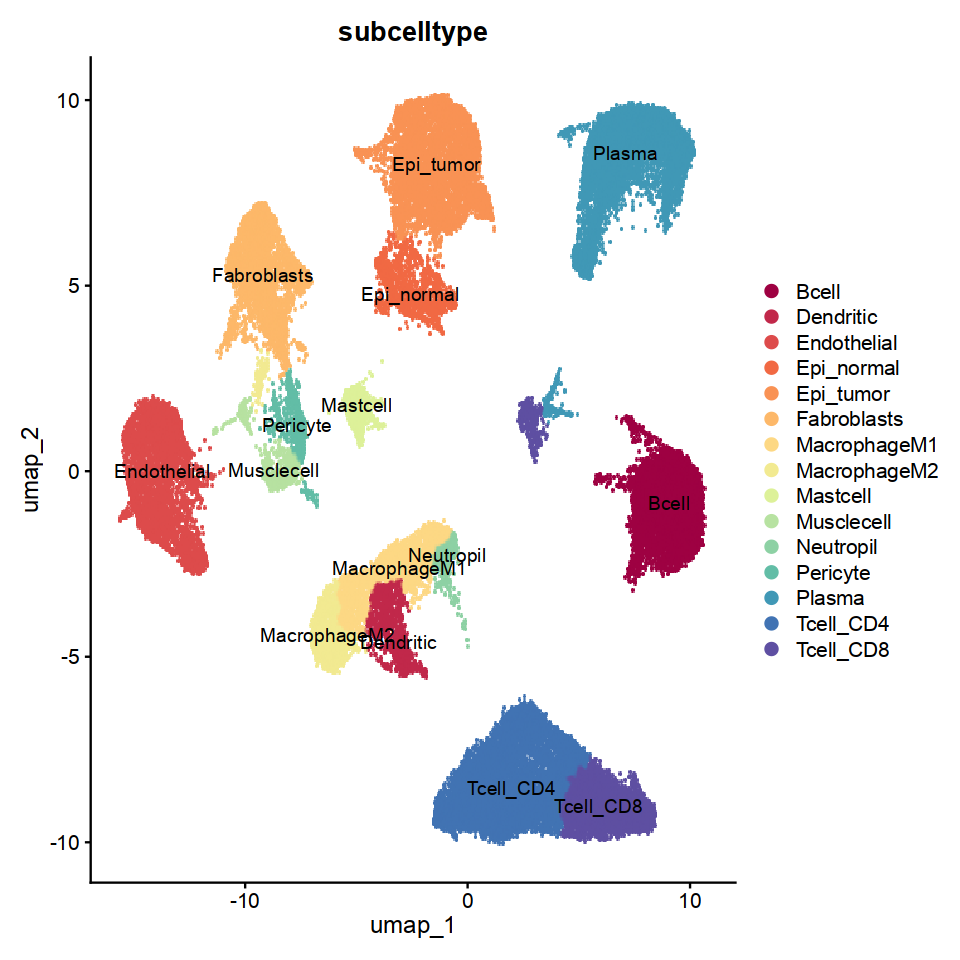

In [41]:
p_fullannotation

In [42]:
ggsave(filename = "GCA_UMAP_fullannotation.pdf",plot = p_fullannotation,width = 8,height = 8)

In [43]:
# Visualization
options(repr.plot.height=14,repr.plot.width=16)
p_dim_split <- DimPlot(GCA_obj_subset, reduction = "umap", group.by = c("subcelltype"),
                       raster = TRUE,pt.size = 2,split.by="sample",ncol=4,
                       cols = colorRampPalette(brewer.pal(10, "Spectral"))(15))

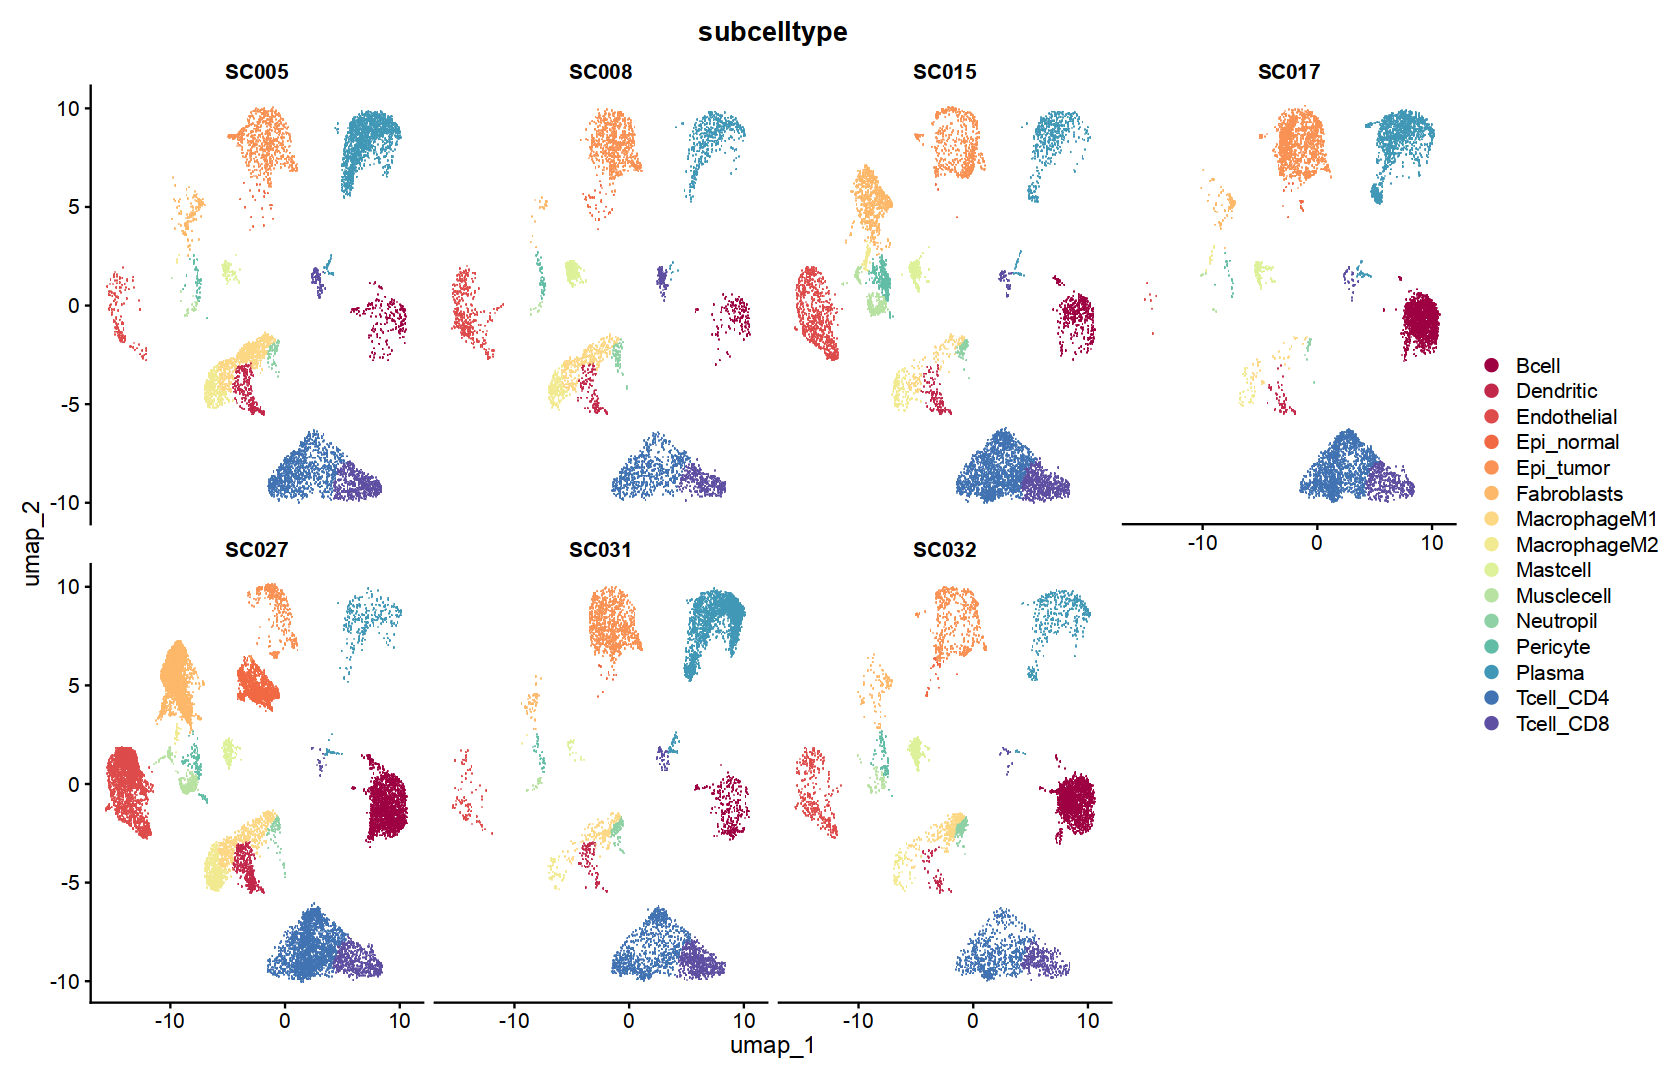

In [44]:
options(repr.plot.height=9,repr.plot.width=14)
p_dim_split

In [45]:
ggsave(filename = "GCA_Umap.Celltype.bySample.pdf",plot = p_dim_split,height =9 ,width =14)

In [102]:
saveRDS(GCA_obj_subset,file = "GCA_obj_subset_celltype.Rdata")

In [1]:
GCA_obj_subset <- readRDS("GCA_obj_subset_celltype.Rdata")

### find allmarkers

In [63]:
Idents(GCA_obj_subset)  = GCA_obj_subset$subcelltype

In [ ]:
# find markers for every cluster compared to all remaining cells, report only the positive
# ones
gca.markers <- FindAllMarkers(GCA_obj_subset, only.pos = TRUE)

In [65]:
gca.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1&p_val_adj<0.05) -> gca.markers.sig

In [66]:
saveRDS(object =gca.markers.sig,file = "markergene.RDS" )

In [73]:
gca.markers.sig$cluster %>% unique()

[1] Tcell_CD8    Endothelial  Plasma       Tcell_CD4    MacrophageM1
 [6] Bcell        MacrophageM2 Musclecell   Epithelium   Neutropil   
[11] Dendritic    Mastcell     Fabroblasts  Pericyte    
14 Levels: Tcell_CD8 Endothelial Plasma Tcell_CD4 MacrophageM1 ... Pericyte

In [74]:
gca.markers.sig  %>% filter(cluster=="MacrophageM2")%>% .[1:10,7]  %>% as.character()

[1] "c(\"C1QB\", \"C1QA\", \"C1QC\", \"MS4A7\", \"LGMN\", \"MS4A6A\", \"TYROBP\", \"MS4A4A\", \"AIF1\", \"FCER1G\")"

### macrophage M1

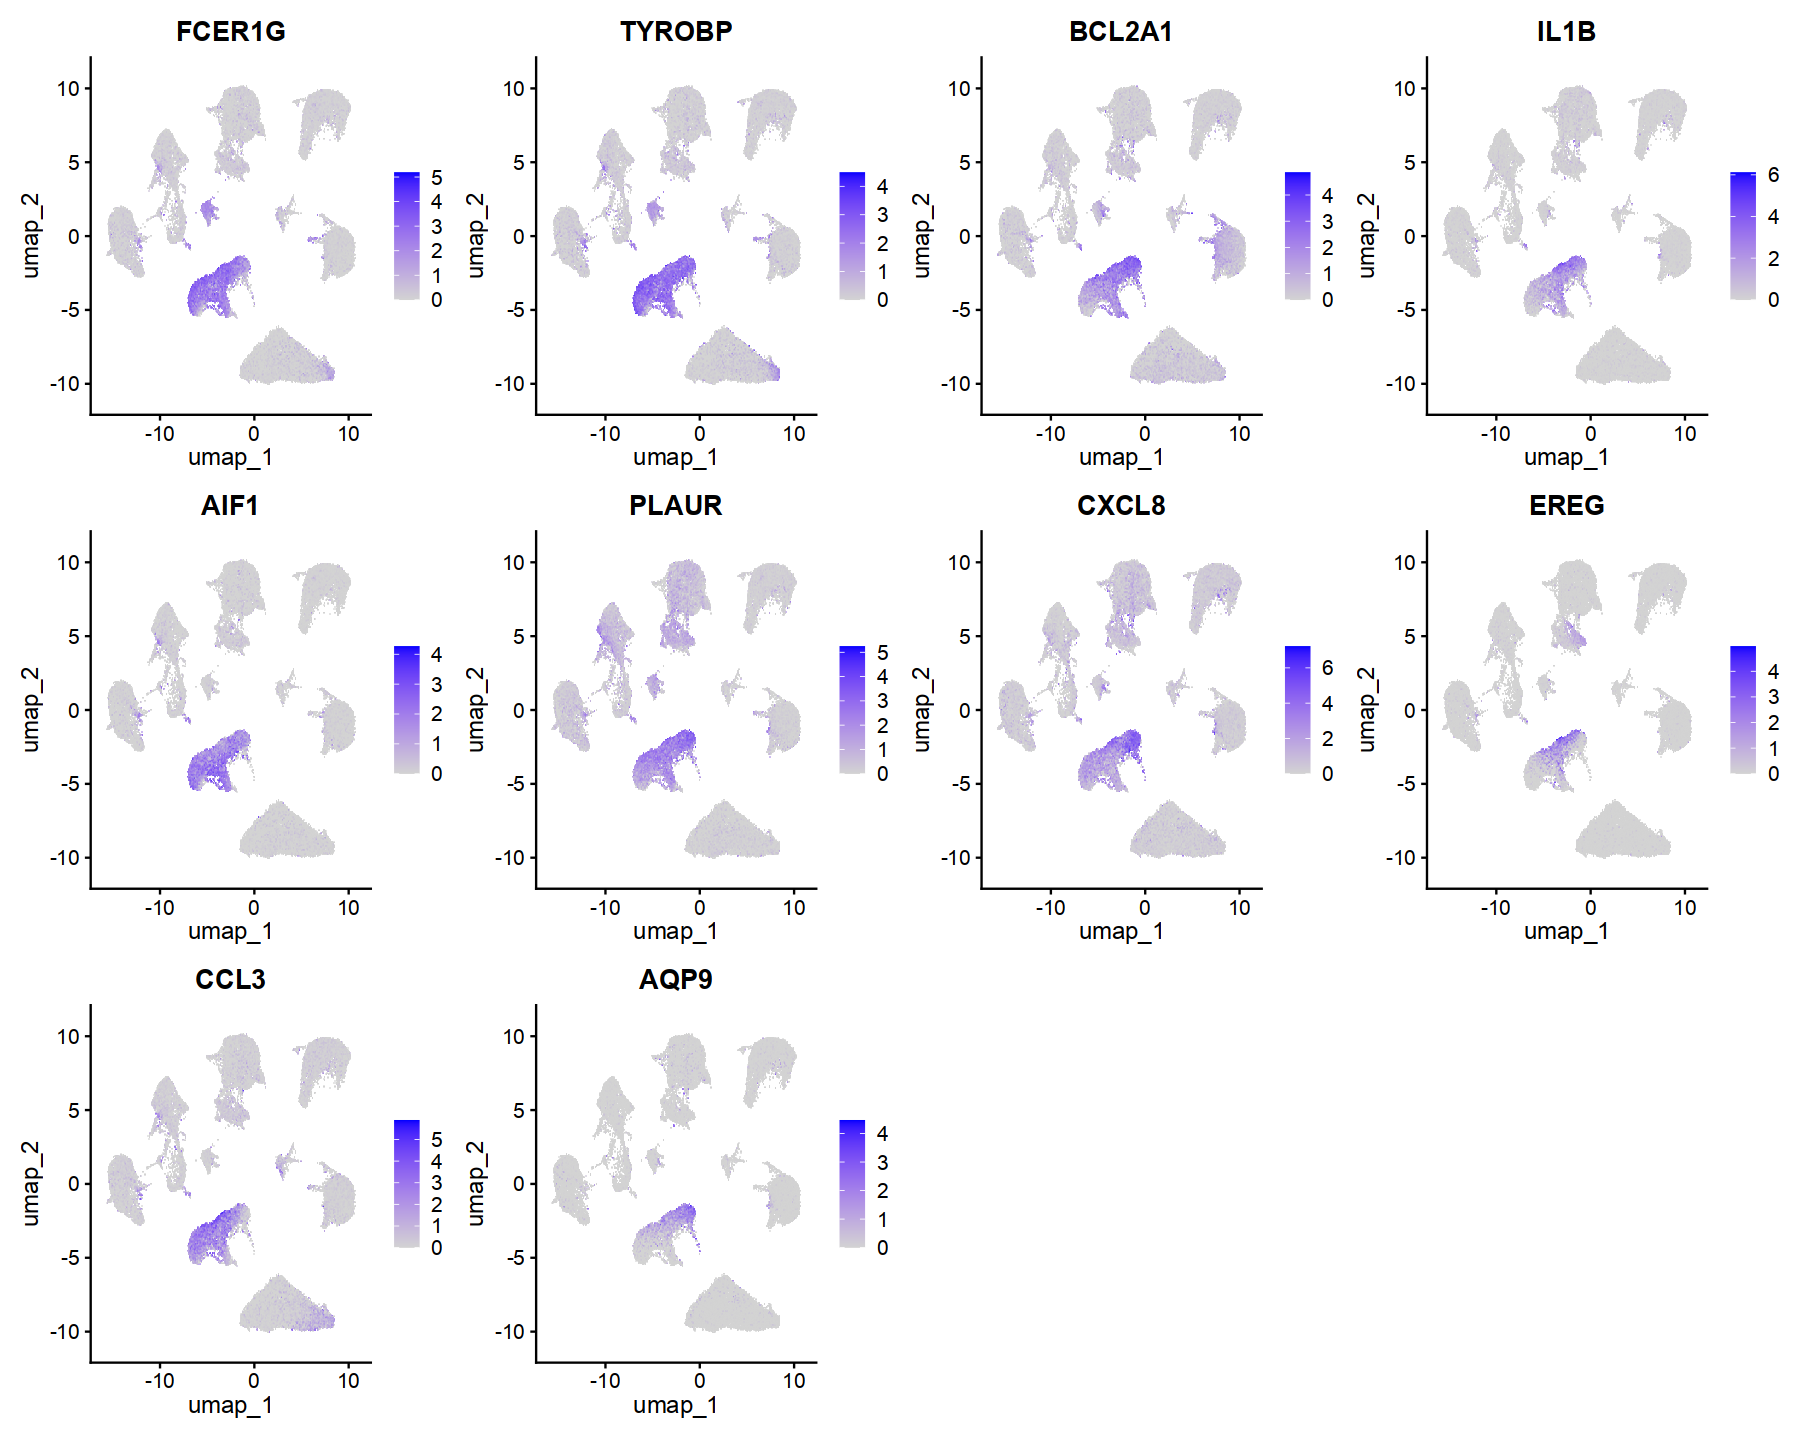

In [69]:
options(repr.plot.height=12,repr.plot.width=15)
FeaturePlot(GCA_obj_subset,  features = c("FCER1G", "TYROBP", "BCL2A1", "IL1B", "AIF1", 
                                          "PLAUR", "CXCL8", "EREG", "CCL3", "AQP9"),
                          raster = TRUE,pt.size = 2)

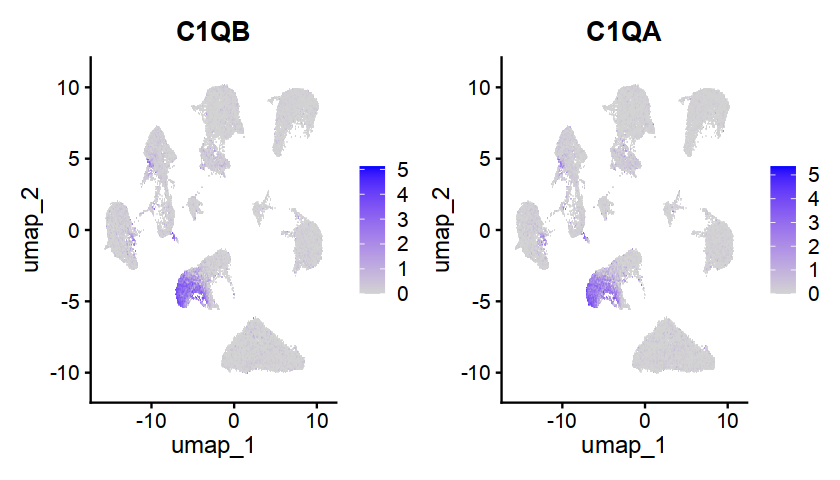

In [78]:
options(repr.plot.height=4,repr.plot.width=7)
FeaturePlot(GCA_obj_subset,  features =c("C1QB", "C1QA"),
                          raster = TRUE,pt.size = 2)

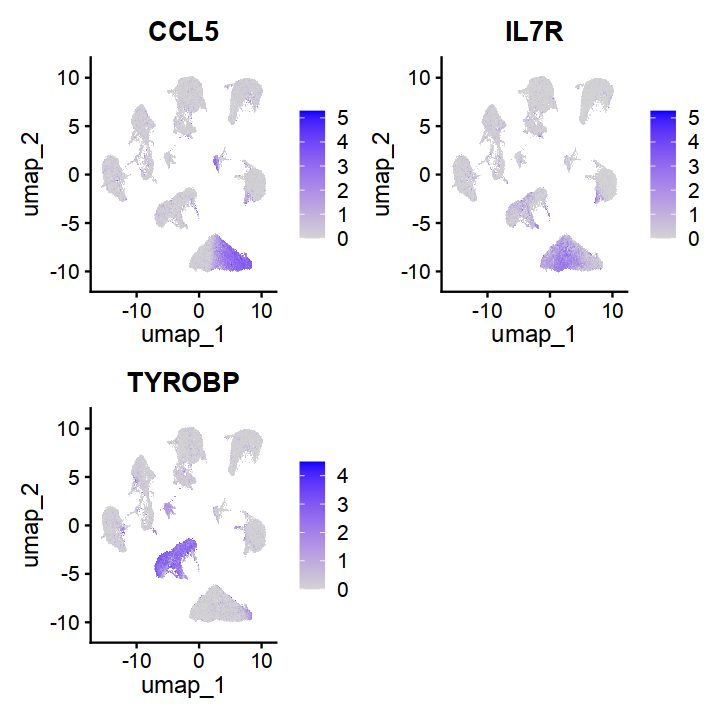

In [79]:
options(repr.plot.height=6,repr.plot.width=6)
FeaturePlot(GCA_obj_subset, features = c("CCL5","IL7R","TYROBP"), 
                          raster = TRUE,pt.size = 2)

In [72]:
# run sctransform
GCA_obj_subset <- SCTransform(GCA_obj_subset, vars.to.regress = "percent.mt", verbose = FALSE,
                              ncells = 3000,conserve.memory=TRUE)

In [ ]:
ls()

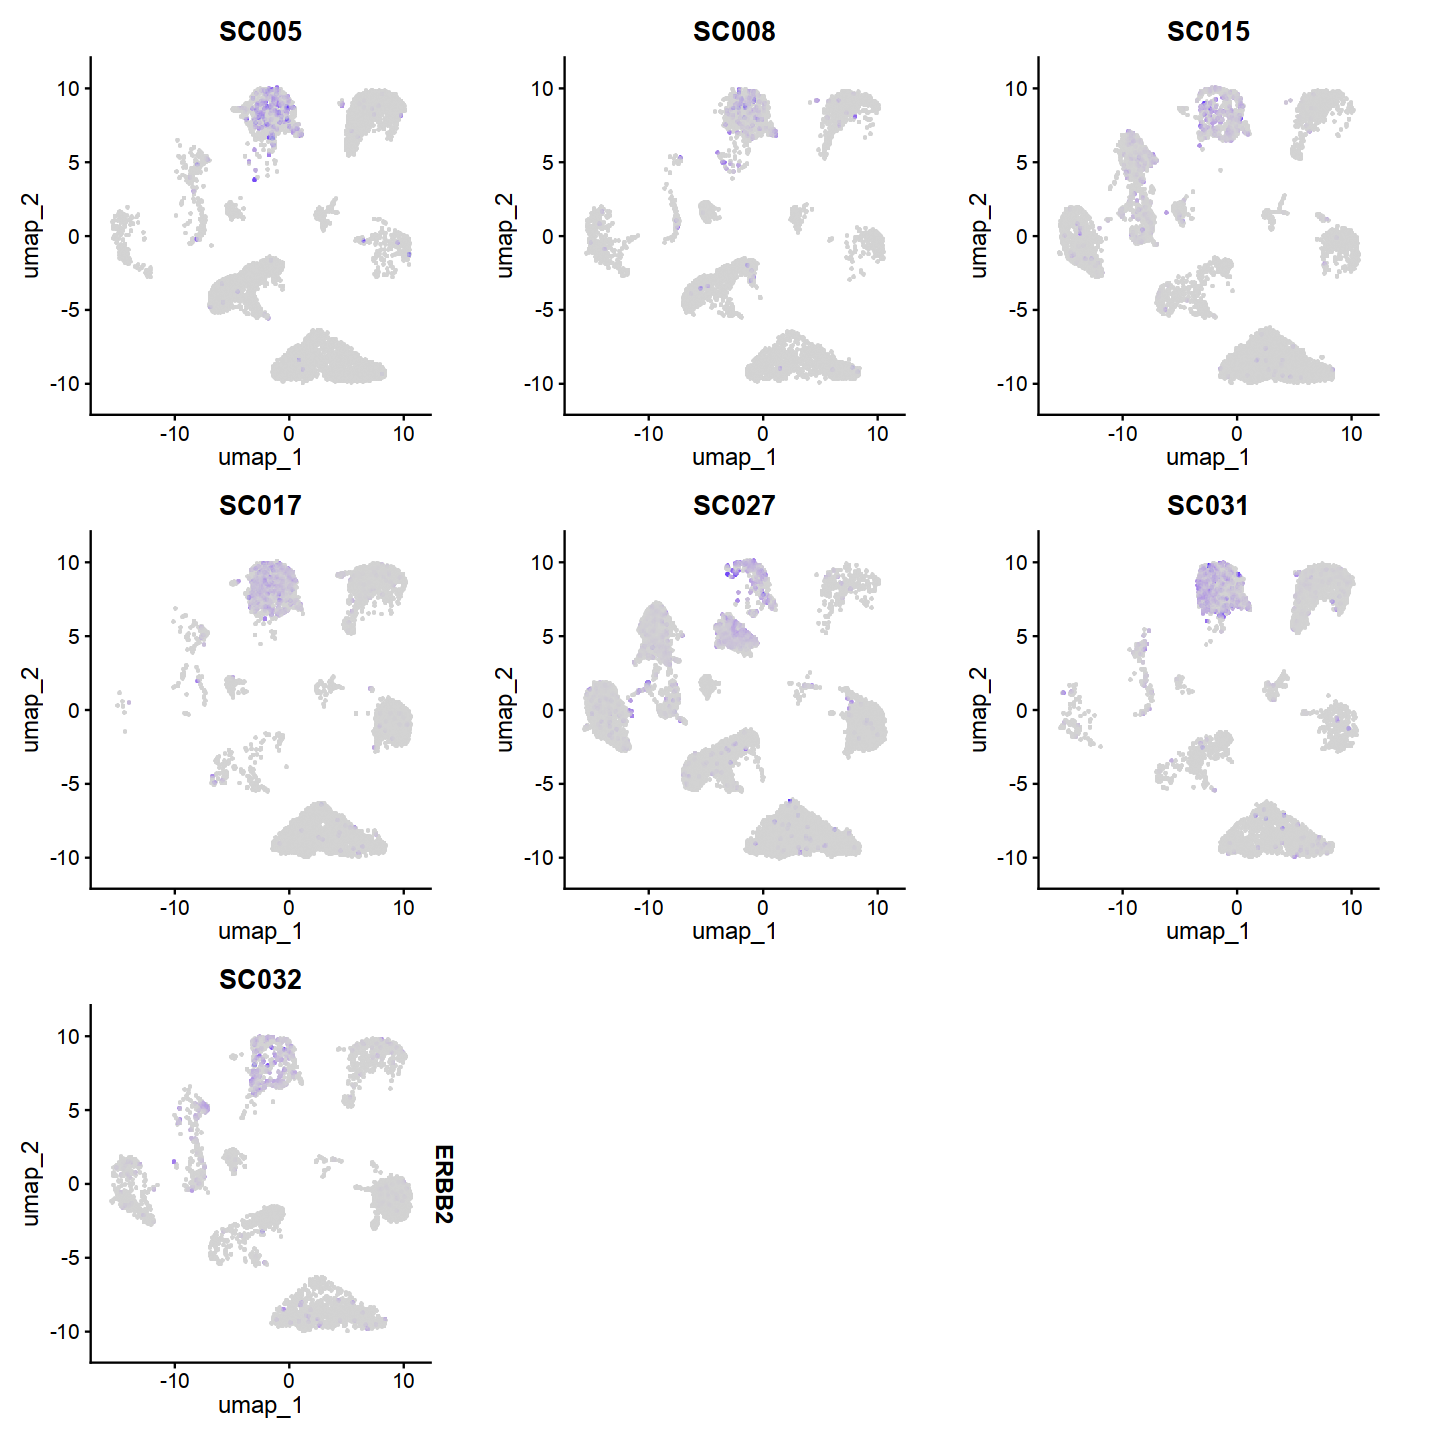

In [86]:
options(repr.plot.height=12,repr.plot.width=12)
FeaturePlot(GCA_obj_subset, features = c("ERBB2"), split.by = "sample",
                          raster = TRUE,pt.size = 4) + patchwork::plot_layout(ncol = 3, nrow = 3)

### distribution

In [48]:
ERBB2_group <- read.table('../04.groupERBB2/ERBB2_7.txt',header=T)

In [49]:
GCA_obj_subset@meta.data -> metadata

In [50]:
metadata %>% count(sample,subcelltype) -> sample_subcelltype_number

In [51]:
head(sample_subcelltype_number)

,sample,subcelltype,n
,<chr>,<chr>,<int>
1,SC005,Bcell,202
2,SC005,Dendritic,280
3,SC005,Endothelial,151
4,SC005,Epi_normal,24
5,SC005,Epi_tumor,709
6,SC005,Fabroblasts,145


In [52]:
sample_subcelltype_number %>% group_by(sample) %>% 
    reframe(Percentage = n/sum(n),celltype = subcelltype)%>% as.data.frame() -> sample_subcelltype_number2

In [53]:
sample_subcelltype_number2$sample <-  factor(sample_subcelltype_number2$sample,levels = rownames(ERBB2_group))

In [54]:
options(repr.plot.height=6,repr.plot.width=8)
p_dis <- ggplot(sample_subcelltype_number2, aes(fill=celltype, y=Percentage, x=sample)) + theme_bw()+
    theme(axis.text.x = element_text(angle=45,hjust=1,color='black'))+
    geom_bar(position="stack", stat="identity")

In [55]:
sample_subcelltype_number2$celltype %>% unique() %>% length()

[1] 15

In [56]:
p_dis <- p_dis+ scale_fill_manual(values = colorRampPalette(brewer.pal(10, "Spectral"))(15))

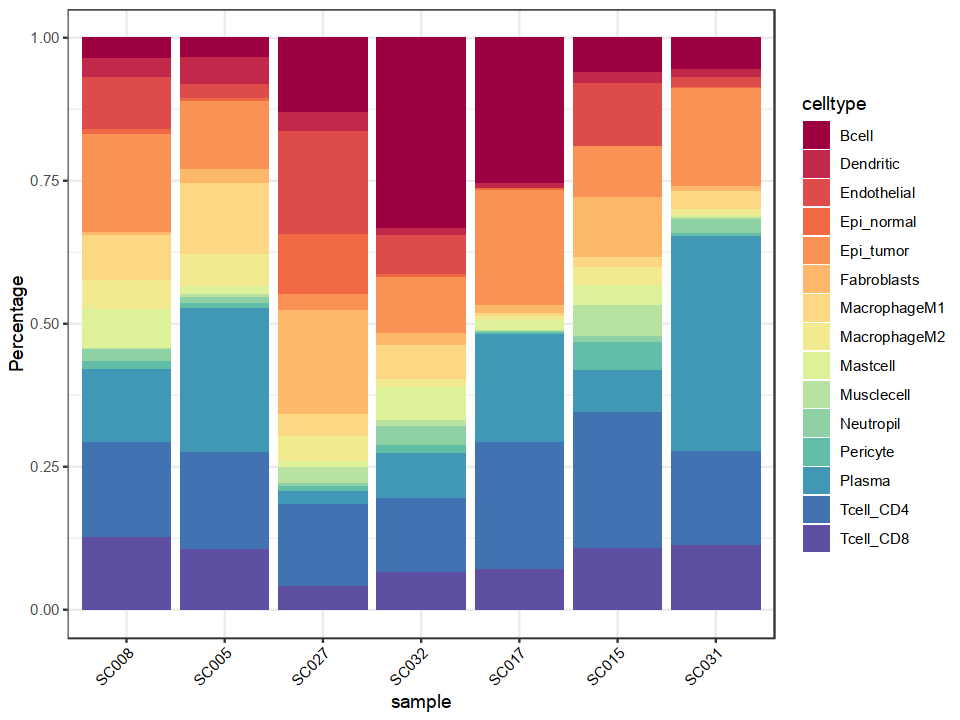

In [57]:
options(repr.plot.height=6,repr.plot.width=8)
p_dis

In [58]:
ggsave(filename = "Celltype_bar.pdf",plot =p_dis ,width = 8,height = 6)

In [59]:
sample_subcelltype_number2$celltype %>% unique()

[1] "Bcell"        "Dendritic"    "Endothelial"  "Epi_normal"   "Epi_tumor"   
 [6] "Fabroblasts"  "MacrophageM1" "MacrophageM2" "Mastcell"     "Musclecell"  
[11] "Neutropil"    "Pericyte"     "Plasma"       "Tcell_CD4"    "Tcell_CD8"

In [60]:
colorRampPalette(brewer.pal(10, "Spectral"))(15)

[1] "#9E0142" "#C1284A" "#DD4B4B" "#F16943" "#F99254" "#FDB869" "#FDD884"
 [8] "#F2EA91" "#DDF199" "#B7E2A1" "#8DD1A4" "#62BDA6" "#4098B6" "#4173B3"
[15] "#5E4FA2"

In [62]:
sample_subcelltype_number2 %>% filter(celltype=="Fabroblasts")

sample,Percentage,celltype
<fct>,<dbl>,<chr>
SC005,0.024423109,Fabroblasts
SC008,0.005391528,Fabroblasts
SC015,0.103630751,Fabroblasts
SC017,0.012979351,Fabroblasts
SC027,0.182041643,Fabroblasts
SC031,0.008931894,Fabroblasts
SC032,0.020310881,Fabroblasts
